# NekComp NASA polynomial refits

In [290]:
import cantera as ct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print(f"Running Cantera Version: {ct.__version__}")

Running Cantera Version: 3.0.0


In [291]:
plt.rcParams['font.size'] = '11'
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [292]:
from cycler import cycler
new_cycler = (cycler(color=[[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4940, 0.1840, 0.5560], 
                            [0.4660, 0.6740, 0.1880], [0.3010, 0.7450, 0.9330], [0.6350, 0.0780, 0.1840], 'darkgreen']))
plt.rc('axes', prop_cycle=new_cycler)

## Setup

In [293]:
# gas = ct.Solution('hydrogen_34.yaml')
# gas = ct.Solution('h2-oconaire.yaml')
# gas = ct.Solution('A2skeletal.yaml')
# gas = ct.Solution("n2_he.yaml")
gas = ct.Solution("air1.yaml")

In [294]:
# # detonation
# Tmin = 200
# Tmax = 4000

# # deflagration
# Tmin = 300
# Tmax = 2000

# deflagration
Tmin = 200
Tmax = 1000

In [295]:
nspec = len(gas.Y)
dT = 1
nT = int((Tmax-Tmin)/dT+1)
T = np.linspace(Tmin,Tmax,nT)

## Ref values $h_i^0$ and $s_i^0$

In [296]:
# ref values
Patm = 101325
R_u = 8.3144598
T0 = 298.15
xx = np.ones(len(gas.X))
gas.TPX = T0, Patm, xx
mw = gas.molecular_weights*1e-3

In [297]:
h0 = gas.partial_molar_enthalpies*1e-3/mw
df = open('h0.dat','w')
for i in range(h0.size):
    df.write(str(h0[i])+"\n")

In [298]:
print(h0)

[5.10761046e-04 5.10424091e+01]


In [299]:
s0 = np.zeros(nspec)
df = open('s0.dat','w')
for b in range(nspec):
    xx = np.zeros(len(gas.X))
    xx[b]=1
    gas.TPX = T0, Patm, xx
    s0[b] = gas.partial_molar_entropies[b]*1e-3/mw[b]
    df.write(str(s0[b])+"\n")
    # print(gas.species_names[b] + " = " + str(s0[b]*mw[b]))

In [300]:
print(s0)

[6411.28501978 6836.30472777]


In [301]:
# set mixture composition 
# only relevant for species specific entropies
# these will differ from polynomial calcs unless xx=[1,...,1]
# mixture entropy s=sum(Y_i*s_i) corrected regardless because of Y_i contribution in partial pressure
xx = np.ones(len(gas.X))
gas.TPX = T0, Patm, xx

## Cantera values

In [302]:
h_c=np.zeros((nT,nspec))
cp_c=np.zeros((nT,nspec))
u_c=np.zeros((nT,nspec))
s_c=np.zeros((nT,nspec))

In [303]:
for b in range(nspec):
    for i in range(nT):
        
        # set Temp
        temp0 = T[i]
            
        # Cantera
        gas.TPX = temp0, Patm, xx
        h_c[i,b] = gas.partial_molar_enthalpies[b]*1e-3/mw[b]
        cp_c[i,b] = gas.partial_molar_cp[b]*1e-3/mw[b]
        u_c[i,b] = gas.partial_molar_int_energies[b]*1e-3/mw[b]
        s_c[i,b] = gas.partial_molar_entropies[b]*1e-3/mw[b]

In [304]:
clrs=[[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4940, 0.1840, 0.5560], 
                            [0.4660, 0.6740, 0.1880], [0.3010, 0.7450, 0.9330], [0.6350, 0.0780, 0.1840], 
                            'darkgreen', 'orange', 'black']

## Form polynomial fits

In [305]:
np2 = 5
a = np.zeros(np2*nspec)

In [306]:
def getCpNew(temp0,a,np2):
    cp1 = 0.0
    for i in range(np2):
        cp1 = cp1 + a[i]*temp0**i
    return cp1

In [307]:
def getHNew(temp0,a,np2,ho):
    h1 = ho
    for i in range(np2):
        h1 = h1 + a[i]*(temp0**(i+1)-298.15**(i+1))/(i+1)
    return h1

In [308]:
def getSNew(temp0,a,np2,so):
    s1 = so
    for i in range(np2):
        s1 = s1 + a[i]*(temp0**(i+1)-298.15**(i+1))/(i+1)
    return s1

In [309]:
# get the polynomial fit
for b in range(nspec):
    cp_fit = cp_c[:,b]
    fit1 = np.flip(np.polyfit(T, cp_fit, np2-1))
    a[b*np2:b*np2+np2] = fit1

In [310]:
h_n=np.zeros((nT,nspec))
cp_n=np.zeros((nT,nspec))
s_n=np.zeros((nT,nspec))

In [311]:
# h, cp
for b in range(nspec):
    for i in range(nT):
        
        # set Temp
        temp0 = T[i]
        
        # updated cp and h with continuous polynomials
        j = b*np2
        cm1 = a[j:j+np2]
        cp_n[i,b] = getCpNew(temp0,cm1,np2)
        h_n[i,b] = getHNew(temp0,cm1,np2,h0[b])

In [312]:
# s
for i in range(nT):
    temp0 = T[i]
    gas.TPX = temp0, Patm, xx
    for b in range(nspec):
        ppi = gas.density*max(1e-16,gas.Y[b])*R_u*temp0/mw[b]    
        j = b*np2
        s_n[i,b] = s0[b] + a[j]*np.log(temp0/298.18)-(R_u/mw[b])*np.log(ppi/101325.0)
        for k in np.arange(1,np2):
            s_n[i,b] = s_n[i,b] + a[j+k]*(temp0**k-298.15**k)/k

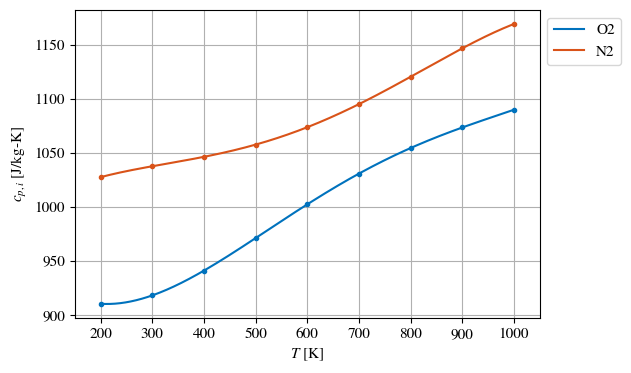

In [313]:
# cp_i
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, cp_c[:,b],label=gas.species_names[b],color=clrs[b])
    ax.plot(T, cp_n[:,b],color=clrs[b],linestyle='',marker='o',markersize=3,markevery=100)
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$c_{p,i}$ [J/kg-K]");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,2.2e4);

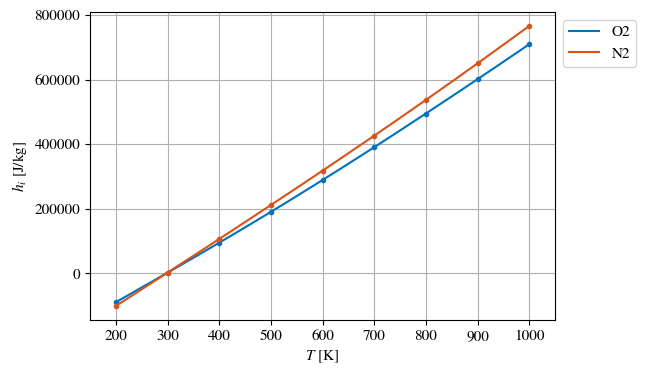

In [314]:
# h_i
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, h_c[:,b],label=gas.species_names[b],color=clrs[b])
    ax.plot(T, h_n[:,b],color=clrs[b],linestyle='',marker='o',markersize=3,markevery=100)
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$h_i$ [J/kg]");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,2.2e4);

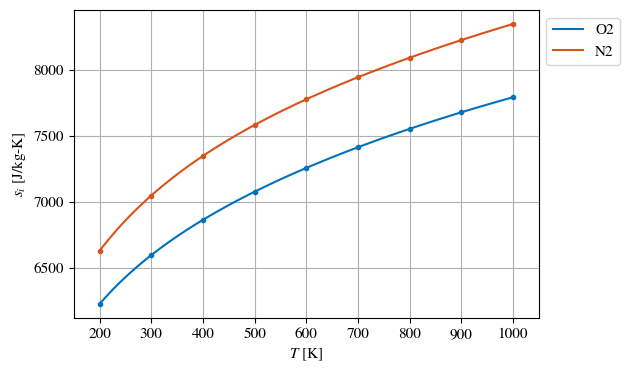

In [315]:
#s_i
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, s_c[:,b],label=gas.species_names[b],color=clrs[b])
    ax.plot(T, s_n[:,b],color=clrs[b],linestyle='',marker='o',markersize=3,markevery=100)
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$s_i$ [J/kg-K]");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,2.2e4);

In [316]:
ss_n = np.zeros(nT)
for b in range(nspec):
    ss_n = ss_n + gas.Y[b]*s_n[:,b]

In [317]:
ss_c = np.zeros(nT) 
for i in range(nT):

    # set Temp
    temp0 = T[i]

    # Cantera
    gas.TPX = temp0, Patm, xx
    ss_c[i] = gas.entropy_mass   

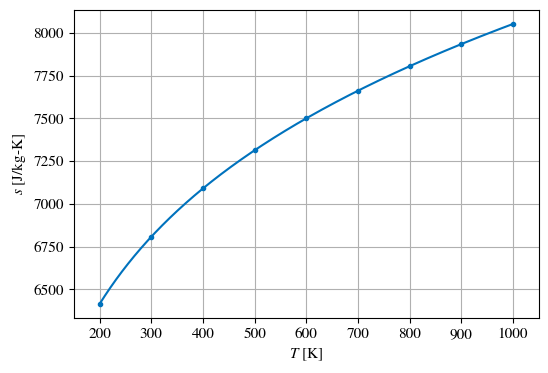

In [318]:
fig,ax = plt.subplots(figsize=(6,4))
ax.plot(T,ss_c,color=clrs[0])
ax.plot(T,ss_n,color=clrs[0],linestyle='',marker='o',markersize=3,markevery=100)
ax.grid();
#ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$s$ [J/kg-K]");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,2.2e4);

In [319]:
df = open('aa.dat','w')
for i in range(a.size):
    df.write(str(a[i])+"\n")

## Calculate $b_i$ coefficients

In [320]:
bi = np.zeros((np2+1)*nspec)

In [321]:
for b in range(nspec):

    sum1 = 0
    j = b*np2
    for c in range(np2):
        sum1 = sum1 + (a[j+c]/(c+1))*298.15**(c+1) 
        
    g = b*(np2+1)
    for c in range(np2+1):
        if(c == 0):
            bi[g+c] = h0[b] - sum1
        elif(c == 1):
            bi[g+c] = a[j+c-1]-R_u/mw[b]
        else:
            bi[g+c] = a[j+c-1]/c          

In [322]:
u_n=np.zeros((nT,nspec))

In [323]:
for b in range(nspec):
    for i in range(nT):
        
        # set Temp
        temp0 = T[i]
        
        # internal energy
        u_n[i,b] = 0.
        j = b*(np2+1)
        for c in range(np2+1):
            u_n[i,b] = u_n[i,b] + bi[j+c]*temp0**c

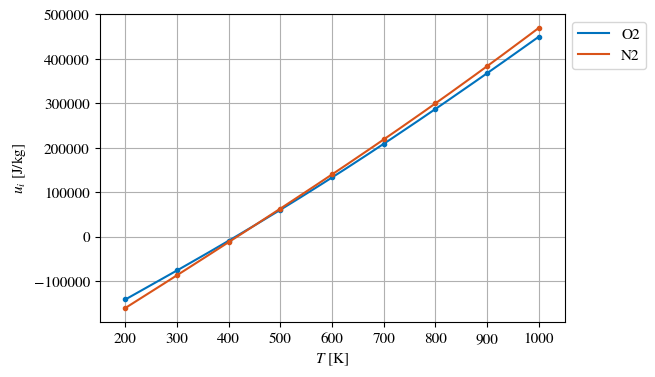

In [324]:
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, u_c[:,b],label=gas.species_names[b],color=clrs[b])
    ax.plot(T, u_n[:,b],color=clrs[b],linestyle='',marker='o',markersize=3,markevery=100)
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$u_i$ [J/kg]");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(-0.5e8,0.5e8);

## Calculate errors

In [325]:
e_cp = np.zeros((nT,nspec))
e_h  = np.zeros((nT,nspec))
e_u  = np.zeros((nT,nspec))
e_s  = np.zeros((nT,nspec))

In [326]:
for b in range(nspec):
    e_cp[:,b] = abs(cp_n[:,b]-cp_c[:,b])/np.max(abs(cp_n[:,b]))
    e_h[:,b] = abs(h_n[:,b]-h_c[:,b])/np.max(abs(h_n[:,b]))
    e_u[:,b] = abs(u_n[:,b]-u_c[:,b])/np.max(abs(u_n[:,b]))
    e_s[:,b] = abs(s_n[:,b]-s_c[:,b])/np.max(abs(s_n[:,b]))

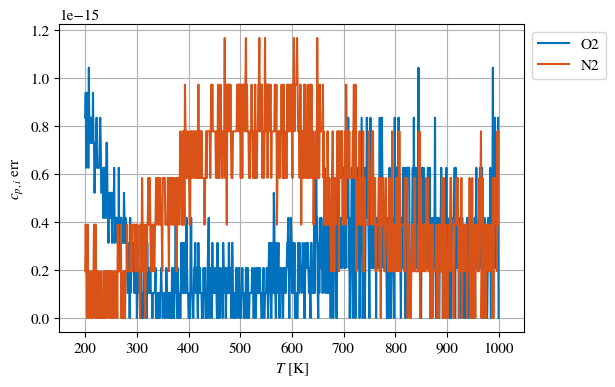

In [327]:
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, e_cp[:,b],label=gas.species_names[b],color=clrs[b])
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$c_{p,i}$ err");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(-0.5e8,0.5e8);

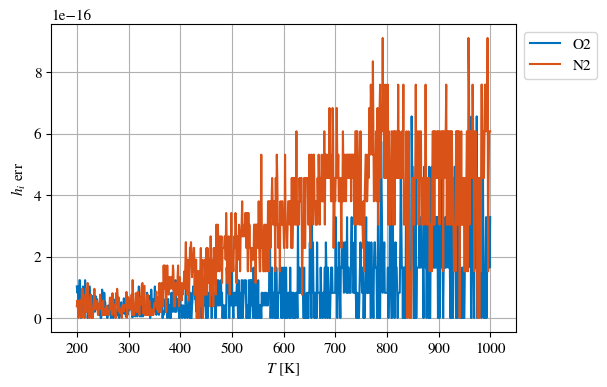

In [328]:
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, e_h[:,b],label=gas.species_names[b],color=clrs[b])
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$h_i$ err");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(-0.5e8,0.5e8);

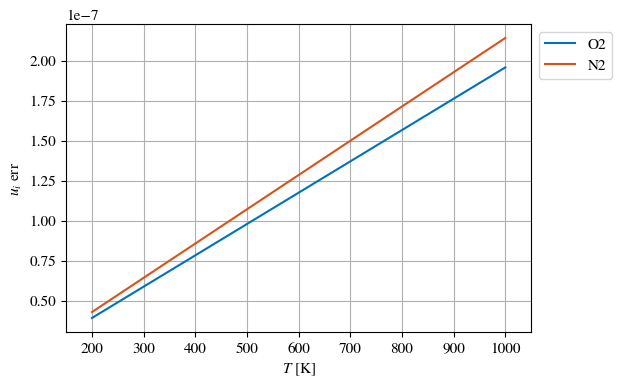

In [329]:
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, e_u[:,b],label=gas.species_names[b],color=clrs[b])
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$u_i$ err");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,0.1);

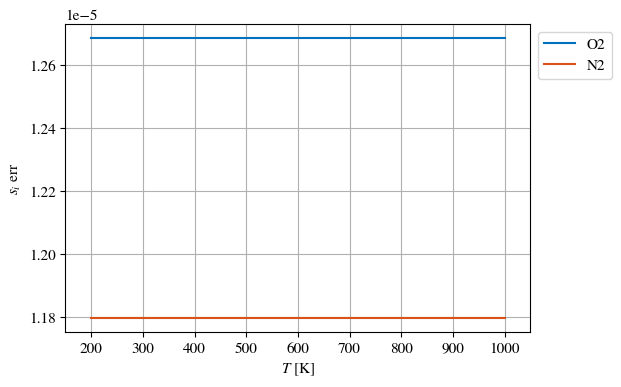

In [330]:
fig,ax = plt.subplots(figsize=(6,4))
for b in range(nspec):
    ax.plot(T, e_s[:,b],label=gas.species_names[b],color=clrs[b])
ax.grid();
# ax.legend();
ax.legend(bbox_to_anchor=(1, 1));
ax.set_xlabel(r"$T$ [K]");
ax.set_ylabel(r"$s_i$ err");
ax.set_xlim(Tmin-50,Tmax+50);
#ax.set_ylim(0,0.1);